## Installing libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from flatten_json import flatten 
import json
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)

## Importing datasets

The following datasets are from my Spotify account which include:
- My streaming history
- My streaming history in music(2019-2020)
- My streaming history in music(2021-2024)
- My streaming history in videos(2023-2024)

In [46]:
streaming_history = pd.read_json('StreamingHistory_music_0.json')
podcasts = pd.read_json('StreamingHistory_podcast_0.json')
sh_19_20 = pd.read_json('Streaming_History_Audio_2019-2021_0.json')
sh_21_24 = pd.read_json('Streaming_History_Audio_2021-2024_1.json')
shvideo_23_24 = pd.read_json('Streaming_History_Video_2023-2024.json')

In [47]:
streaming_history

,endTime,artistName,trackName,msPlayed
0,2023-11-26 16:08,Pixies,Monkey Gone to Heaven,136530
1,2023-11-26 16:08,The White Stripes,I Just Don't Know What to Do With Myself,38957
2,2023-11-30 11:44,Erik Satie,Satie: 6 Gnossiennes: V. No. 5,6440
3,2023-11-30 11:45,Erik Satie,"Le Fils des étoiles, 3 Preludes: I. Prelude de...",971
4,2023-11-30 11:45,Erik Satie,"3 Gymnopédies: No. 1, Lent et douloureux",7695
...,...,...,...,...
2751,2024-11-22 13:32,Ruby Haunt,Sanctuary,1940
2752,2024-11-22 13:32,Fever Ray,If I Had a Heart,228400
2753,2024-11-23 15:49,Ruby Haunt,Answering Machine,309000
2754,2024-11-23 15:50,Ruby Haunt,Blue Hour,79134


In [48]:
podcasts

,endTime,podcastName,episodeName,msPlayed
0,2023-11-22 18:08,Huberman Lab,"Dr. Natalie Crawford: Female Hormone Health, F...",1077070
1,2023-11-29 10:58,Huberman Lab,"Dr. Natalie Crawford: Female Hormone Health, F...",1770830
2,2023-11-30 15:19,Huberman Lab,"Dr. Natalie Crawford: Female Hormone Health, F...",669250
3,2023-12-02 18:11,Huberman Lab,"Dr. Natalie Crawford: Female Hormone Health, F...",1328940
4,2023-12-10 10:58,Huberman Lab,"Dr. Natalie Crawford: Female Hormone Health, F...",257010
...,...,...,...,...
395,2024-11-11 19:50,Super Data Science: ML & AI Podcast with Jon K...,821: The Skills You Need to Be an Effective Da...,54610
396,2024-11-17 20:13,Women in Data Podcast,"Ep.123 Elevate Your Career: Growth Mindset, S...",1709511
397,2024-11-17 20:14,Super Data Science: ML & AI Podcast with Jon K...,821: The Skills You Need to Be an Effective Da...,31309
398,2024-11-22 09:33,Super Data Science: ML & AI Podcast with Jon K...,821: The Skills You Need to Be an Effective Da...,53963


## Dropping columns

In [49]:
sh_19_20 = sh_19_20.drop(columns=['platform','conn_country','ip_addr','spotify_track_uri','spotify_episode_uri','incognito_mode','offline'])
sh_21_24 = sh_21_24.drop(columns=['platform','conn_country','ip_addr','spotify_track_uri','spotify_episode_uri','incognito_mode','offline'])
shvideo_23_24 = shvideo_23_24.drop(columns=['platform','conn_country','ip_addr','spotify_track_uri','spotify_episode_uri','incognito_mode','offline'])

## Changing the columns of dataframes

In [50]:
sh_19_20 = sh_19_20.rename(columns={'master_metadata_track_name':'track_name',
                                   'master_metadata_album_artist_name':'artist_name',
                                   'master_metadata_album_album_name':'album_name'})

sh_21_24= sh_21_24.rename(columns={'master_metadata_track_name':'track_name',
                                   'master_metadata_album_artist_name':'artist_name',
                                   'master_metadata_album_album_name':'album_name'})

shvideo_23_24= shvideo_23_24.rename(columns={'master_metadata_track_name':'track_name',
                                   'master_metadata_album_artist_name':'artist_name',
                                   'master_metadata_album_album_name':'album_name'})

In [51]:
sh_19_20

,ts,ms_played,track_name,artist_name,album_name,episode_name,episode_show_name,reason_start,reason_end,shuffle,skipped,offline_timestamp
0,2019-01-25T07:55:33Z,29040,Issues,Julia Michaels,Nervous System,None,None,playbtn,endplay,True,False,NaN
1,2019-01-25T07:56:39Z,65073,Prologue (Firewatch),insaneintherainmusic,Prologue (Firewatch),None,None,clickrow,endplay,True,False,NaN
2,2019-01-25T07:59:49Z,1560,Jim Cain,Bill Callahan,Sometimes I Wish We Were An Eagle,None,None,playbtn,fwdbtn,True,False,NaN
3,2019-01-25T07:59:50Z,1358,Goji Berry Sunset,Jealous of the Birds,Parma Violets,None,None,fwdbtn,fwdbtn,True,False,NaN
4,2019-01-25T07:59:51Z,0,Best Boy,The Saxophones,If You're in the Water,None,None,fwdbtn,fwdbtn,True,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
18298,2021-05-17T05:31:51Z,4613,Apocalypse,Cigarettes After Sex,Cigarettes After Sex,None,None,trackdone,logout,False,False,NaN
18299,2021-05-17T05:33:10Z,45880,you should see me in a crown,Billie Eilish,"WHEN WE ALL FALL ASLEEP, WHERE DO WE GO?",None,None,clickrow,endplay,False,False,NaN
18300,2021-05-17T05:37:37Z,266070,God Knows I Tried,Lana Del Rey,Honeymoon,None,None,clickrow,endplay,False,False,NaN
18301,2021-05-17T05:42:23Z,261100,Darkest Hour,Sevdaliza,Shabrang,None,None,clickrow,endplay,False,False,NaN


## Combining the two datasets

In [52]:
df = pd.concat([sh_19_20,sh_21_24])
df = pd.DataFrame(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28652 entries, 0 to 10348
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ts                 28652 non-null  object 
 1   ms_played          28652 non-null  int64  
 2   track_name         27373 non-null  object 
 3   artist_name        27373 non-null  object 
 4   album_name         27373 non-null  object 
 5   episode_name       1279 non-null   object 
 6   episode_show_name  1279 non-null   object 
 7   reason_start       28652 non-null  object 
 8   reason_end         28652 non-null  object 
 9   shuffle            28652 non-null  bool   
 10  skipped            28652 non-null  bool   
 11  offline_timestamp  7294 non-null   float64
dtypes: bool(2), float64(1), int64(1), object(8)
memory usage: 2.5+ MB


## Some queries

### Some filtering

In [54]:
min_msplayed = df[df['ms_played'] < 300 ].head(60)
min_msplayed

,ts,ms_played,track_name,artist_name,album_name,episode_name,episode_show_name,reason_start,reason_end,shuffle,skipped,offline_timestamp
4,2019-01-25T07:59:51Z,0,Best Boy,The Saxophones,If You're in the Water,None,None,fwdbtn,fwdbtn,True,False,NaN
7,2019-01-25T09:17:38Z,0,Gods & Monsters,Lana Del Rey,Born To Die - The Paradise Edition,None,None,clickrow,trackerror,False,False,NaN
1020,2019-02-07T06:12:40Z,0,"She Loves Me, She Loves Me Not",She Wants Revenge,She Wants Revenge,None,None,trackdone,logout,False,False,NaN
1036,2019-02-07T06:49:50Z,260,Demon Cleaner,Kyuss,Welcome to Sky Valley,None,None,fwdbtn,fwdbtn,False,False,NaN
1262,2019-02-12T09:14:38Z,0,House of the Rising Sun,The Animals,The Singles Plus,None,None,trackdone,unexpected-exit-while-paused,True,False,NaN
1450,2019-02-20T18:50:03Z,0,Born This Way,Lady Gaga,Born This Way,None,None,trackdone,fwdbtn,True,False,NaN
1471,2019-02-21T09:15:26Z,0,P.I.M.P.,50 Cent,Get Rich Or Die Tryin',None,None,trackdone,unexpected-exit-while-paused,True,False,NaN
1508,2019-02-25T12:52:35Z,0,Iris,The Goo Goo Dolls,Dizzy up the Girl,None,None,trackdone,unexpected-exit-while-paused,True,False,NaN
1523,2019-02-26T07:40:58Z,0,Nothing Compares 2 U,Sinéad O'Connor,I Do Not Want What I Haven't Got,None,None,trackdone,unexpected-exit-while-paused,True,False,NaN
1617,2019-02-27T07:37:28Z,0,Zombie,The Cranberries,No Need To Argue,None,None,trackdone,endplay,False,False,NaN


In [56]:
lanadelrey = df[df['artist_name'] == 'Lana Del Rey']
lanadelrey

,ts,ms_played,track_name,artist_name,album_name,episode_name,episode_show_name,reason_start,reason_end,shuffle,skipped,offline_timestamp
7,2019-01-25T09:17:38Z,0,Gods & Monsters,Lana Del Rey,Born To Die - The Paradise Edition,None,None,clickrow,trackerror,False,False,NaN
14,2019-01-25T10:45:34Z,356150,Cherry,Lana Del Rey,Lust For Life,None,None,clickrow,logout,False,False,NaN
25,2019-01-25T14:41:41Z,9940,Diet Mountain Dew,Lana Del Rey,Born To Die - The Paradise Edition,None,None,clickrow,endplay,False,False,NaN
26,2019-01-25T14:48:29Z,283870,Born To Die,Lana Del Rey,Born To Die - The Paradise Edition,None,None,clickrow,endplay,False,False,NaN
48,2019-01-25T19:21:48Z,6090,Million Dollar Man,Lana Del Rey,Born To Die - The Paradise Edition,None,None,clickrow,endplay,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
10326,2024-11-24T11:55:14Z,321053,Yayo,Lana Del Rey,Born To Die - The Paradise Edition,None,None,trackdone,trackdone,False,False,1.732449e+09
10329,2024-11-24T11:59:36Z,2929,Terrence Loves You,Lana Del Rey,Honeymoon,None,None,fwdbtn,fwdbtn,False,True,1.732450e+09
10330,2024-11-24T12:04:07Z,272485,Happiness is a butterfly,Lana Del Rey,Norman Fucking Rockwell!,None,None,fwdbtn,trackdone,False,False,1.732450e+09
10333,2024-11-24T12:15:17Z,24482,Wildflower Wildfire,Lana Del Rey,Wildflower Wildfire,None,None,trackdone,endplay,False,True,1.732450e+09


In [59]:
df[(df['ms_played'] < 300) & (df['artist_name'] == 'Nicholas Britell')]

,ts,ms_played,track_name,artist_name,album_name,episode_name,episode_show_name,reason_start,reason_end,shuffle,skipped,offline_timestamp
4929,2023-02-13T09:36:05Z,0,"Rondo in F Minor for Piano and Orchestra - ""Ke...",Nicholas Britell,Succession: Season 2 (Music from the HBO Series),None,None,fwdbtn,fwdbtn,False,True,1.676281e+09
4974,2023-02-13T11:00:00Z,0,Strings Con Fuoco,Nicholas Britell,Succession: Season 1 (HBO Original Series Soun...,None,None,fwdbtn,backbtn,False,True,1.676286e+09
5025,2023-02-13T12:03:16Z,23,The Middle of the World,Nicholas Britell,Moonlight (Original Motion Picture Soundtrack),None,None,fwdbtn,fwdbtn,False,True,1.676290e+09
5848,2023-03-04T08:16:57Z,196,"Rondo in F Minor for Piano and Orchestra - ""Ke...",Nicholas Britell,Succession: Season 2 (Music from the HBO Series),None,None,trackdone,endplay,False,True,1.677918e+09
7984,2024-04-26T08:39:00Z,0,Strings Con Fuoco,Nicholas Britell,Succession: Season 1 (HBO Original Series Soun...,None,None,clickrow,endplay,False,True,1.714121e+09
7985,2024-04-26T08:39:00Z,0,Strings Con Fuoco,Nicholas Britell,Succession: Season 1 (HBO Original Series Soun...,None,None,clickrow,endplay,False,True,1.714121e+09


#### .loc and .iloc

In [64]:
df.loc[7]

,ms_played,track_name,artist_name,album_name,episode_name,episode_show_name,reason_start,reason_end,shuffle,skipped,offline_timestamp,day,time
7,0,Gods & Monsters,Lana Del Rey,Born To Die - The Paradise Edition,None,None,clickrow,trackerror,False,False,NaN,2019-01-25,09:17:38
7,253493,Candy,Iggy Pop,Brick By Brick,None,None,trackdone,trackdone,False,False,NaN,2021-05-20,06:40:48


In [65]:
df.iloc[7]

ms_played                                             0
track_name                              Gods & Monsters
artist_name                                Lana Del Rey
album_name           Born To Die - The Paradise Edition
episode_name                                       None
episode_show_name                                  None
reason_start                                   clickrow
reason_end                                   trackerror
shuffle                                           False
skipped                                           False
offline_timestamp                                   NaN
day                                          2019-01-25
time                                           09:17:38
Name: 7, dtype: object

#### Changing ms to minutes

In [66]:
df['mplayed'] = df.ms_played.divide(60000)
df.drop('ms_played', axis=1, inplace=True)

In [67]:
df['mplayed']

0        0.484000
1        1.084550
2        0.026000
3        0.022633
4        0.000000
           ...   
10344    3.042050
10345    0.091800
10346    3.771700
10347    0.572767
10348    3.806667
Name: mplayed, Length: 28652, dtype: float64

#### Seperating ts column into two other columns

In [63]:
df['ts'] = pd.to_datetime(df['ts'])
df['day'] = [d.date() for d in df['ts']]
df['time'] = [d.time() for d in df['ts']] 
df.drop('ts', axis=1, inplace=True)


In [61]:
s = streaming_history.groupby('artistName')['msPlayed'].min().sort_values(ascending = False)[:20]
s 

artistName
Jess Benko                316556
MGMT                      299960
Booker T. & the M.G.'s    250125
Billy Joel                248055
Chet Faker                239440
Michl                     230124
Simon & Garfunkel         221957
Sonny J                   188853
Elton John                183440
Hooverphonic              176506
Kiara Leonard             169349
The Motels                169040
Nancy Sinatra             162446
Linn Hope                 157860
May Laude                 150000
Ren Lockhart              149629
Jefferson Airplane        142291
Temperance Lloyd          140823
Domi Nova                 137010
Maya Sarfatto             136658
Name: msPlayed, dtype: int64

In [62]:
streaming_history['artistName'] == "Jess Benko" 

0       False
1       False
2       False
3       False
4       False
        ...  
2751    False
2752    False
2753    False
2754    False
2755    False
Name: artistName, Length: 2756, dtype: bool

In [68]:
p = podcasts.groupby('podcastName')['msPlayed'].min().sort_values(ascending = False)[:20]
p

podcastName
The Subtle Art of Not Giving a F*ck Podcast    3140732
Science Stories                                1660734
Life Kit                                        868360
Switched On                                     209252
Women On Topic                                  167210
Financial Feminist                              156643
Lanita's Secrets                                154180
Thinking in English                             118410
Greek Women in STEM Podcast                     107174
Developer Tea                                    97007
Brain Science: Neuroscience, Behavior            49103
Learning English Conversations                   44173
Data Ideas                                       41240
Data Bytes                                       37392
Woman's Hour                                     32661
CodeNewbie                                       18710
Women in Data Podcast                            18564
Data Engineering Podcast                         1663

## Data visualization

### Histogram

In [ ]:
# plt.figure(figsize=(20,20))
# sns.set_theme()
# most_played_artists_by_count = df.groupby('artist_name')['track_name'].count().sort_values(ascending=False)[:15]


# ax1 = sns.histplot(x=most_played_artists_by_count.index, y = df['mplayed'][:15].index, bins=15)
# ax1.set_xticklabels(ax1.get_xticklabels(),rotation=30)
# print('Popularity Of Artists By Number Of Times Their Song Was Played')

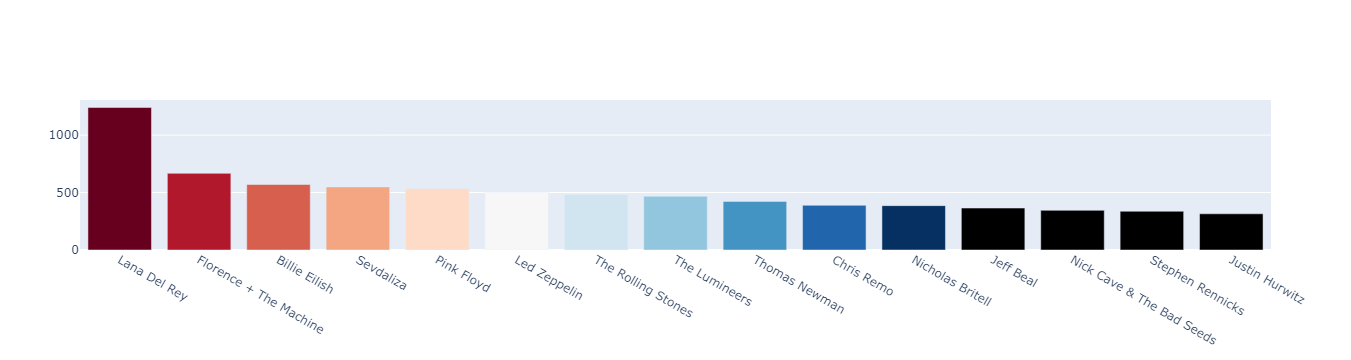

In [69]:
most_played_artists_by_count = df.groupby('artist_name')['track_name'].count().sort_values(ascending=False)[:15]

colors = ['RGB(103, 0, 31)','RGB(178, 24, 43)','RGB(214, 96, 77)','RGB(244, 165, 130)','RGB(253, 219, 199)',
          'RGB(247, 247, 247)','RGB(209, 229, 240)','RGB(146, 197, 222)','RGB(67, 147, 195)','RGB(33, 102, 172)',
          'RGB(5, 48, 97)']

layout = go.Layout(
    title='Popularity Of Artists By Number Of Times Their Song Was Played',
    yaxis= dict(
        title="Number of Times Played",
        gridcolor='rgb(255, 255, 255)',
        zerolinewidth=1,
        ticklen=5,
        gridwidth=2,
        titlefont=dict(size=15)),
    xaxis=dict(title="Artist Name"))

fig = go.Figure(data=[go.Bar(x=most_played_artists_by_count.index,
                             y=most_played_artists_by_count,
                             textposition='auto',
                             opacity=1,
                             marker_color=colors)])
fig.show()

In [ ]:
# plt.figure(figsize=(20,20))
# amount_of_time = df.groupby('artist_name')['mplayed'].sum().sort_values(ascending=False)[:15]

# sns.set_theme()
# ax2 = sns.histplot(x=amount_of_time.index, y = df['mplayed'][:15].index, bins=15)
# ax2.set_xticklabels(ax2.get_xticklabels(),rotation=30)
# print('Popularity of artists by amount of time spent listening to their song') 

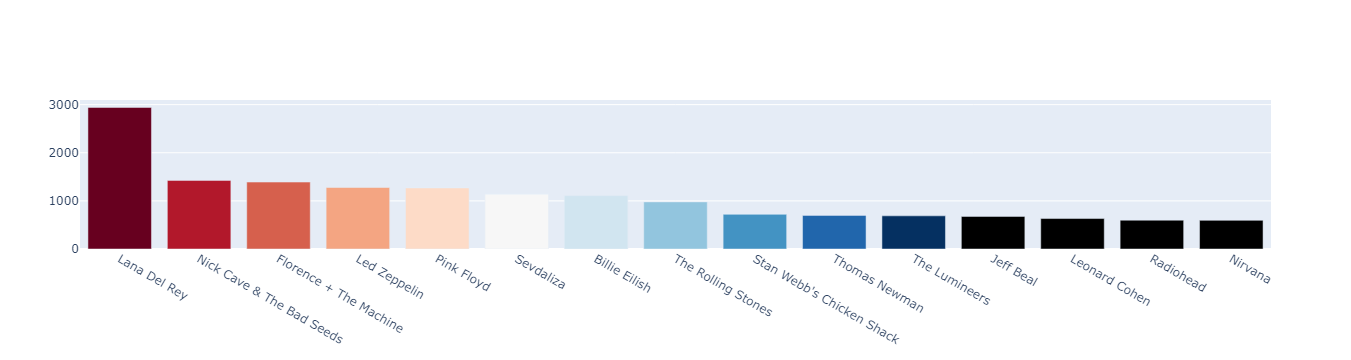

In [70]:
amount_of_time = df.groupby('artist_name')['mplayed'].sum().sort_values(ascending=False)[:15]

colors = ['RGB(103, 0, 31)','RGB(178, 24, 43)','RGB(214, 96, 77)','RGB(244, 165, 130)','RGB(253, 219, 199)',
          'RGB(247, 247, 247)','RGB(209, 229, 240)','RGB(146, 197, 222)','RGB(67, 147, 195)','RGB(33, 102, 172)',
          'RGB(5, 48, 97)']

layout = go.Layout(
    title='Popularity of artists by amount of time spent listening to their song',
    yaxis= dict(
        title='Amount of time (in minutes)',
        gridcolor='rgb(255, 255, 255)',
        zerolinewidth=1,
        ticklen=5,
        gridwidth=2,
        titlefont=dict(size=15)),
    xaxis= dict(
        title = 'Artist Name'))


fig = go.Figure(data=[go.Bar(x=amount_of_time.index,
                             y=amount_of_time,
                             opacity=1,
                            marker_color=colors)])

fig.show()

### Line

In [71]:
dline = df[['day','mplayed']]
dline

,day,mplayed
0,2019-01-25,0.484000
1,2019-01-25,1.084550
2,2019-01-25,0.026000
3,2019-01-25,0.022633
4,2019-01-25,0.000000
...,...,...
10344,2024-11-24,3.042050
10345,2024-11-24,0.091800
10346,2024-11-24,3.771700
10347,2024-11-24,0.572767


Timeline Of My Streaming History


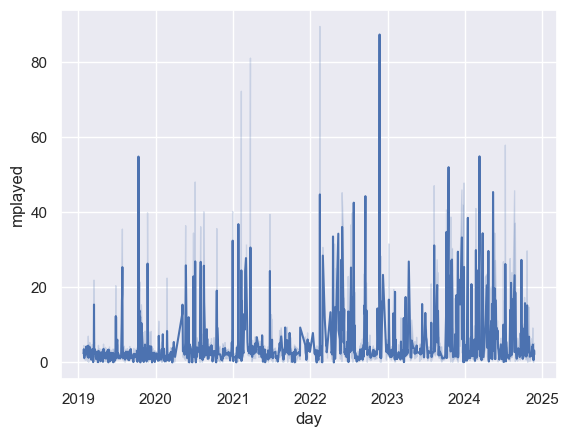

In [72]:
sns.set_theme()
ax3 = sns.lineplot(dline, x='day',y='mplayed')
print("Timeline Of My Streaming History") 

### Pie

In [73]:
df['day_name'] = pd.DatetimeIndex(df['day']).day_name()
dd2 = df[['day_name', 'mplayed']]
d2 = dd2.groupby(by=['day_name'], as_index=False).sum()
d2.head() 

,day_name,mplayed
0,Friday,9976.033567
1,Monday,8446.099600
2,Saturday,7620.934350
3,Sunday,8725.795933
4,Thursday,10829.778850


([<matplotlib.patches.Wedge at 0x23cdb254df0>,
 [Text(0.9791999817358202, 0.501166036128317, 'Monday'),
  Text(0.2445453842082881, 1.0724726360436527, 'Tuesday'),
  Text(-0.563371934158849, 0.9447814899764482, 'Wednesday'),
  Text(-1.0636038438601538, 0.280618715209634, 'Thursday'),
  Text(-0.8626517462282102, -0.6825188383696231, 'Friday'),
  Text(0.1377461114878767, -1.091341380490069, 'Saturday'),
  Text(0.9827661212743799, -0.4941363687033277, 'Sunday')],
 [Text(0.534109080946811, 0.27336329243362745, '15.1%'),
  Text(0.13338839138633896, 0.5849850742056286, '12.7%'),
  Text(-0.3072937822684631, 0.5153353581689717, '11.5%'),
  Text(-0.5801475511964475, 0.15306475375070944, '13.2%'),
  Text(-0.47053731612447824, -0.37228300274706716, '16.3%'),
  Text(0.07513424262975092, -0.5952771166309466, '16.3%'),
  Text(0.5360542479678435, -0.2695289283836333, '14.8%')])

<Figure size 10000x20000 with 0 Axes>

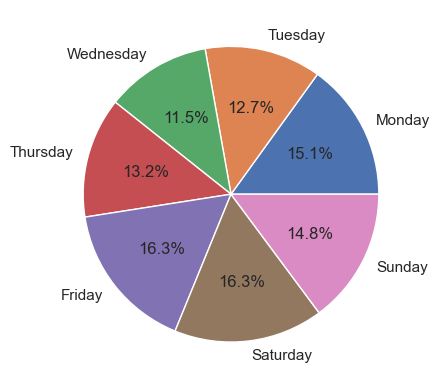

In [74]:
plt.figure(figsize=(100,200))
weights = d2['mplayed']
days = ["Monday", "Tuesday", "Wednesday","Thursday","Friday","Saturday","Sunday"]
fig, ax = plt.subplots()
ax.pie(weights,labels=days, autopct='%1.1f%%') 